#  **Autoregressive Moving Average — $ARMA(p, q)$**

* **Conceituação:** Combina a componente Autoregressiva $AR(p)$ e a componente de Média Móvel $MA(q)$ num único modelo estruturado.

* **Equação Matemática:** $Y_t = c + \sum_{i=1}^{p} \phi_i Y_{t-i} + \epsilon_t + \sum_{j=1}^{q} \theta_j \epsilon_{t-j}$

* **Quando utilizar:**
* A série temporal é estacionária, mas apresenta dependência tanto de valores passados quanto de choques passados.
* Tanto o **ACF**quanto o **PACF** caem suavemente/exponencialmente sem cortes secos, indicando uma mistura de componentes.

# **Criandoa série temporal**

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


## **Definição da série temporal**

In [53]:
phi = np.array([0.7])     # Coeficiente AR(1) = +0.7
theta = np.array([0.4])   # Coeficiente MA(1) = +0.4

ar_params = np.r_[1, -phi]    # [1, -0.7]
ma_params = np.r_[1, theta]   # [1, 0.4]

processo = ArmaProcess(ar_params, ma_params)
print(f"Processo Estacionário: {processo.isstationary}")
print(f"Processo Invertível: {processo.isinvertible}")

processo = ArmaProcess(ar_params, ma_params)


np.random.seed(42)  # Garantir reproducibilidade
n_samples = 500
dados = processo.generate_sample(nsample=n_samples)

# Converter em Pandas Series com índice de datas diárias
datas = pd.date_range(start="2026-01-01", periods=n_samples, freq="D")
serie_modelo_arma = pd.Series(dados, index=datas, name="Serie_ARMA")

Processo Estacionário: True
Processo Invertível: True


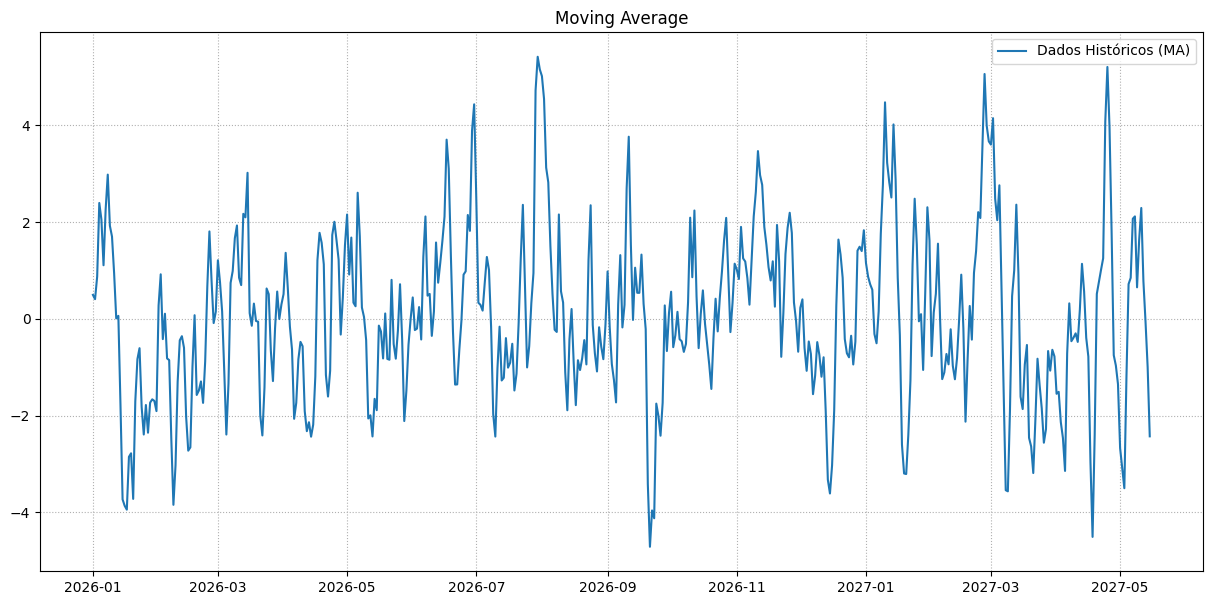

In [54]:
# Gráfico
plt.figure(figsize=(15, 7))
plt.plot(serie_modelo_arma, label='Dados Históricos (MA)')
plt.title('Moving Average')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# **Estudo da Série temporal**
Nesta seção será realizdo o estudo da série temporal, onde serão avaliados:

* Decomposição

* Normalidade da série.
  * Teste de Shapiro-Wilk
  * Grafico QQ_plot
  * Histograma
* Estacionariadade (Teste KPSS)
* Funções de auto correlação (ACF e PACF)

### **Decomposicao**

In [55]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [56]:
decomposicao = seasonal_decompose(serie_modelo_arma, model='additive')

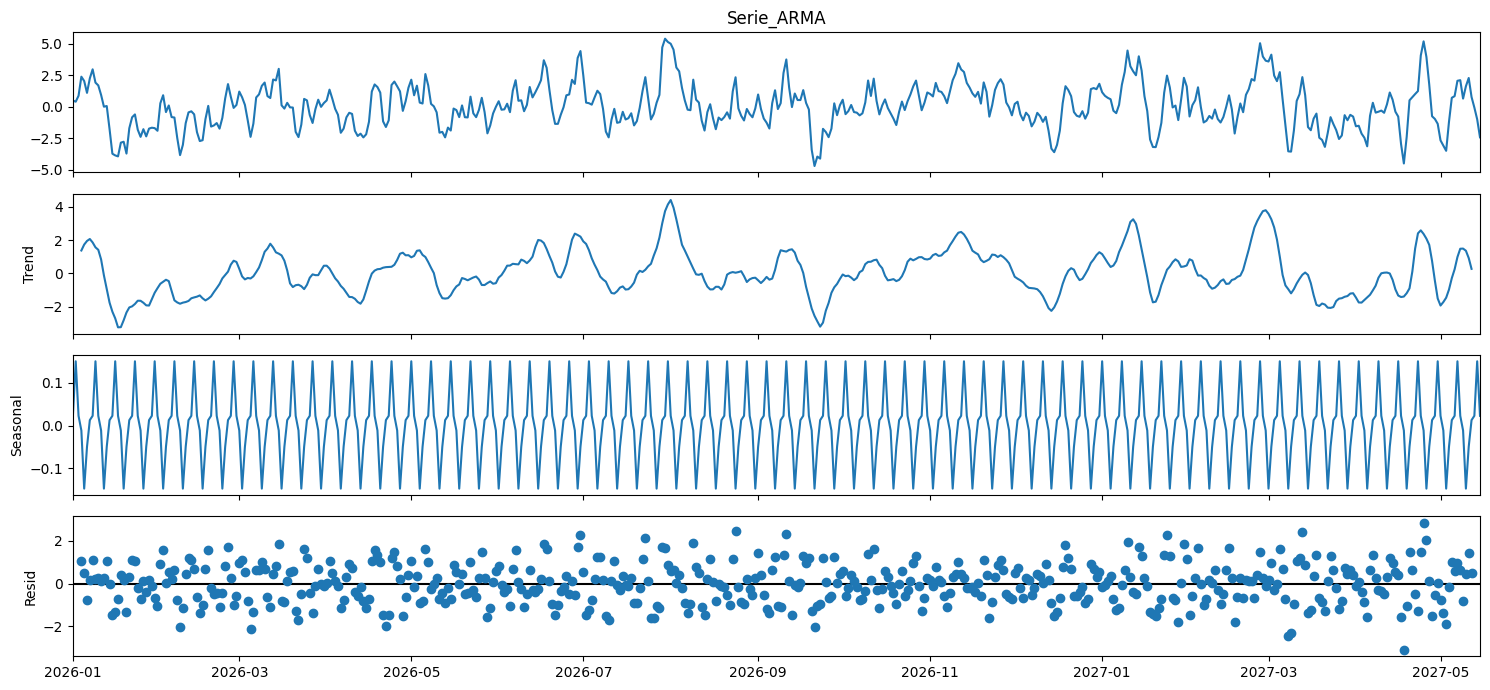

In [57]:
decomposicao.plot()
plt.show()

## **Normalidade da série.**

### **Hipóteses do Teste de Shapiro-Wilk**


O teste avalia duas hipóteses concorrentes:
* **Hipótese Nula ($H_0$):** Os dados seguem uma distribuição normal.
* **Hipótese Alternativa ($H_1$):** Os dados não seguem uma distribuição normal.

**Como Interpretar o P-Valor (p-value)**

* **Se $p \ge 0,05$:** Não há evidências para rejeitar $H_0$. Conclui-se que os resíduos do modelo são aproximadamente normais (modelo validado quanto à normalidade).
* **Se $p < 0,05$:** Rejeita-se $H_0$. Os resíduos não seguem uma distribuição normal, indicando possíveis problemas no modelo (como presenças de outliers ou heterocedasticidade

In [58]:
import scipy.stats as stats

e,p_valor =stats.shapiro(serie_modelo_arma)
print('Estatistica de teste = %.3f, p-valor = %.3f' % (e,p_valor))

Estatistica de teste = 0.993, p-valor = 0.024


In [59]:
if p_valor >= 0.05:
  print('Não há evidências para rejeitar a hipótese nula. Os dados seguem uma distribuição normal.')
else:
  print('Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.')

Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.


### **QQ_plot**

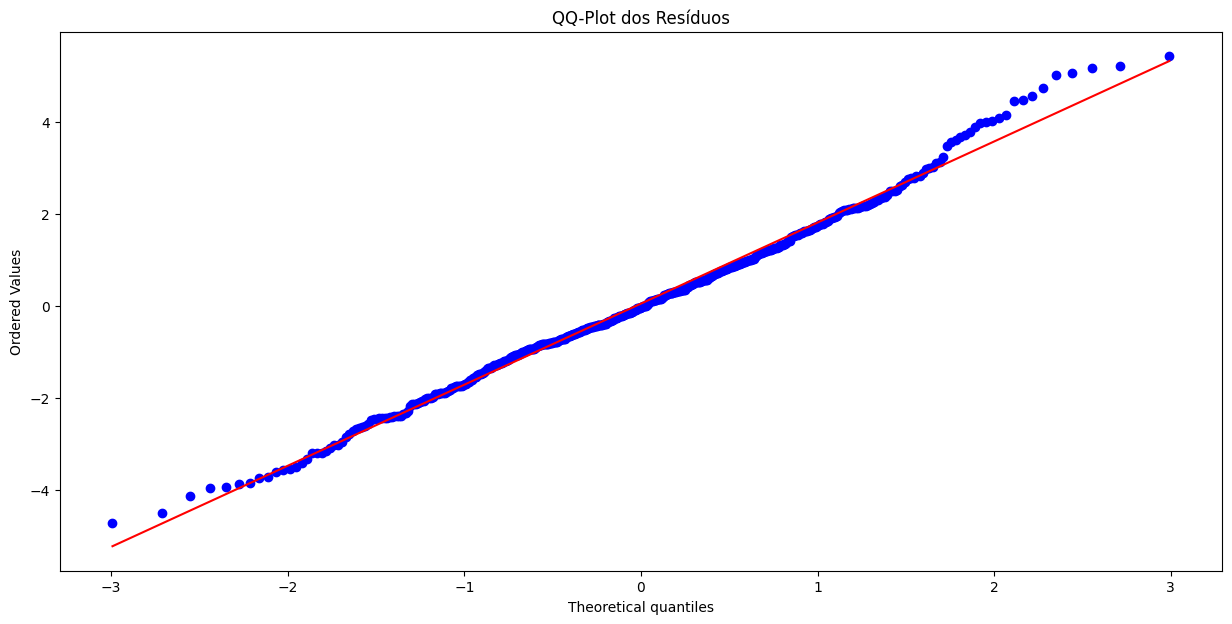

In [60]:
import scipy.stats as stats
stats.probplot(serie_modelo_arma, dist='norm', plot=plt)
plt.title('QQ-Plot dos Resíduos')
plt.show()

### **Histrograma da série**

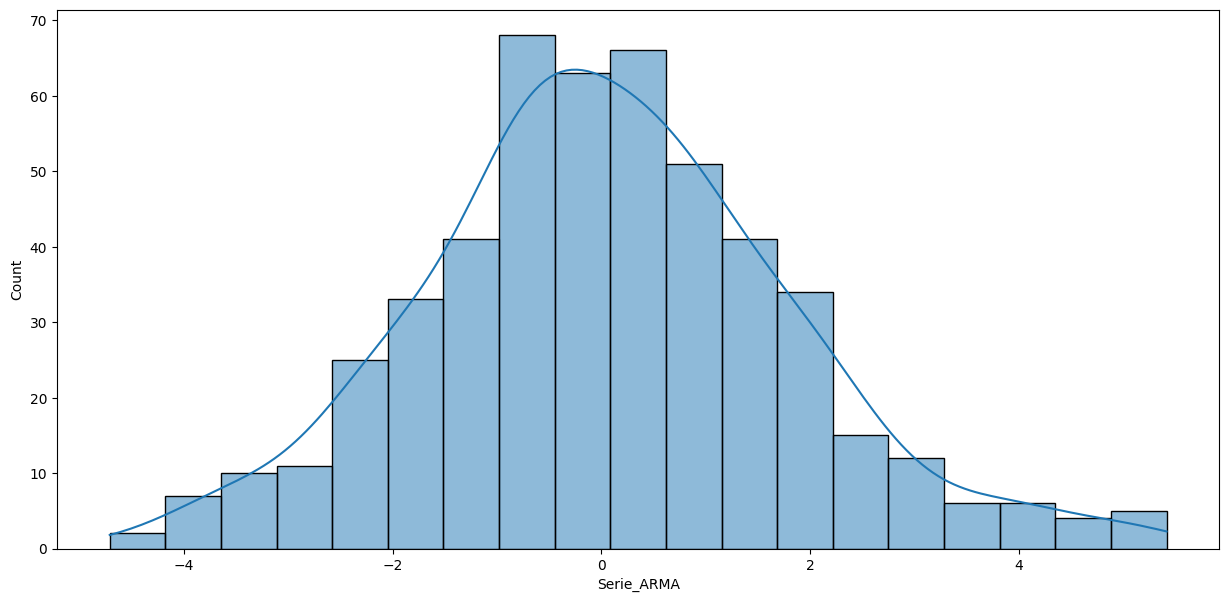

In [61]:
import seaborn as sns
sns.histplot(serie_modelo_arma, kde=True)
plt.show()

## **Estacionaridade da série -Modelo Autoregressivo AR(p)**

O teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin) é um teste estatístico utilizado em séries temporais para verificar se os dados são estacionários em torno de uma média ou de uma tendência determinística.

**Como o Teste Funciona**
* **Hipótese Nula (H₀):** A série temporal é estacionária (em nível ou em tendência).
* **Hipótese Alternativa (H₁):** A série temporal não é estacionária (possui raiz unitária

**Interpretação dos Resultados**
* **p-valor > 0,05** (ou estatística menor que o valor crítico): Você não rejeita a hipótese nula. Os dados indicam que a série é estacionária.
* **p-valor ≤ 0,05** (ou estatística maior que o valor crítico): Você rejeita a hipótese nula. Há fortes evidências de que a série não é estacionár

In [62]:
import statsmodels.tsa.stattools

In [63]:
result_kpss = statsmodels.tsa.stattools.kpss(serie_modelo_arma)
print('Estatistica de teste = %.3f, p-valor = %.3f' % (result_kpss[0], result_kpss[1]))

Estatistica de teste = 0.154, p-valor = 0.100


/tmp/ipykernel_2833/1422014277.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  result_kpss = statsmodels.tsa.stattools.kpss(serie_modelo_arma)
/tmp/ipykernel_2833/1422014277.py:1: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_kpss = statsmodels.tsa.stattools.kpss(serie_modelo_arma)


In [64]:
if p_valor > 0.05:
    print('A série é estacionária')
else:
    print('A série não é estacionária')

A série não é estacionária


##  **Estudo da autocorrelaçao (ACF e PACF)**

In [65]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

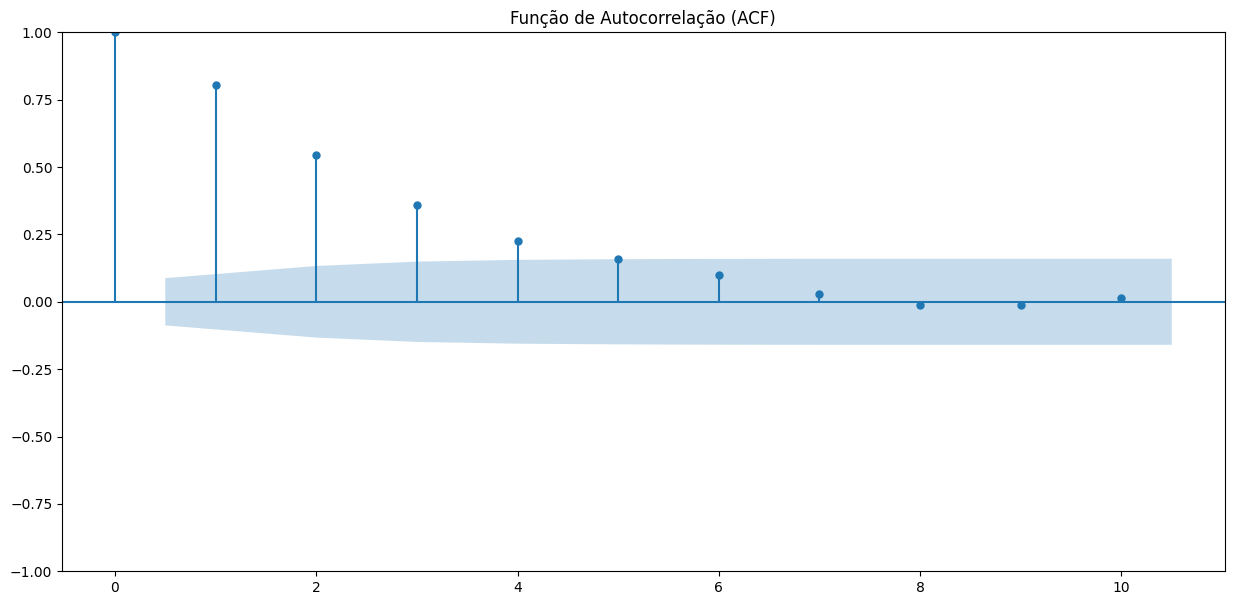

In [66]:
plot_acf(serie_modelo_arma ,lags=10, color='#1f77b4', title='Função de Autocorrelação (ACF)')
plt.show()

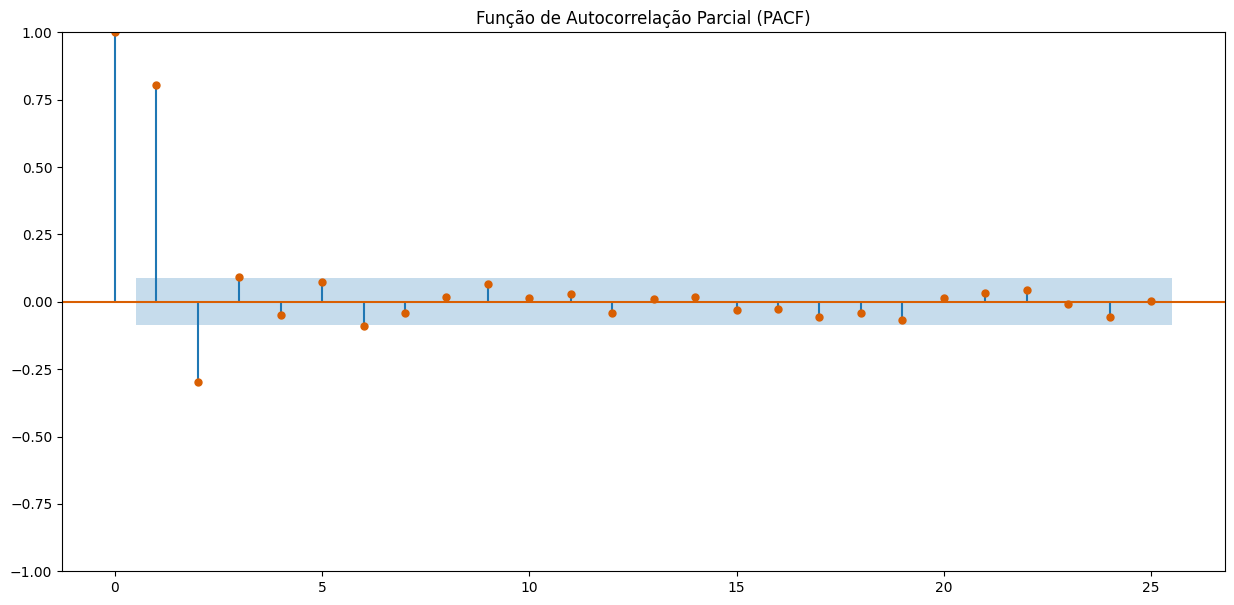

In [67]:
plot_pacf(serie_modelo_arma, lags=25, color='#d95f02', title='Função de Autocorrelação Parcial (PACF)')
plt.show()

# **Implementação do modelo  ARMA**

* Definição do modelo
* Estudo do resíduo
* Aplicação do model

## **Definição do modelo ARMA**

In [68]:
from statsmodels.tsa.arima.model import ARIMA

In [69]:
modelo_arma = ARIMA( serie_modelo_arma , order=(2, 0, 1))

In [70]:
modelo_arma_result = modelo_arma.fit()

In [71]:
print(modelo_arma_result.summary())

                               SARIMAX Results                                
Dep. Variable:             Serie_ARMA   No. Observations:                  500
Model:                 ARIMA(2, 0, 1)   Log Likelihood                -699.827
Date:                Thu, 17 Sep 2026   AIC                           1409.653
Time:                        19:31:42   BIC                           1430.726
Sample:                    01-01-2026   HQIC                          1417.922
                         - 05-15-2027                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0349      0.198      0.177      0.860      -0.353       0.422
ar.L1          0.6269      0.130      4.818      0.000       0.372       0.882
ar.L2          0.0443      0.113      0.394      0.6

## **Estudo do resíduo.**

In [72]:
residuos_modelo_arma = modelo_arma_result.resid

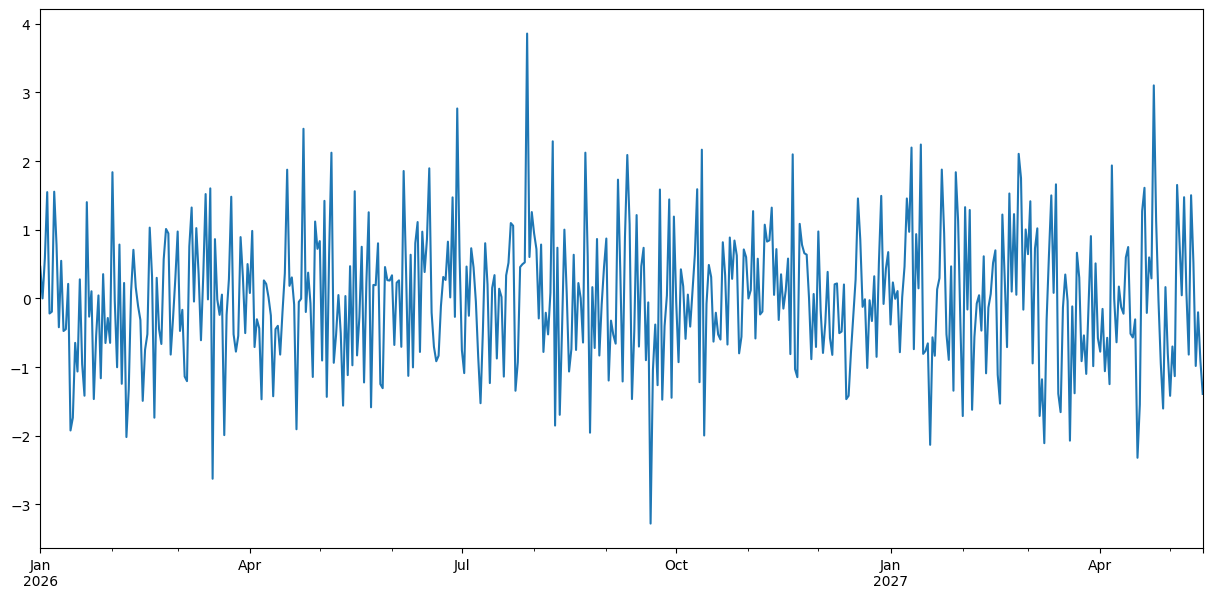

In [73]:
residuos_modelo_arma.plot()
plt.show()

###  **Normalidade do resíduo**

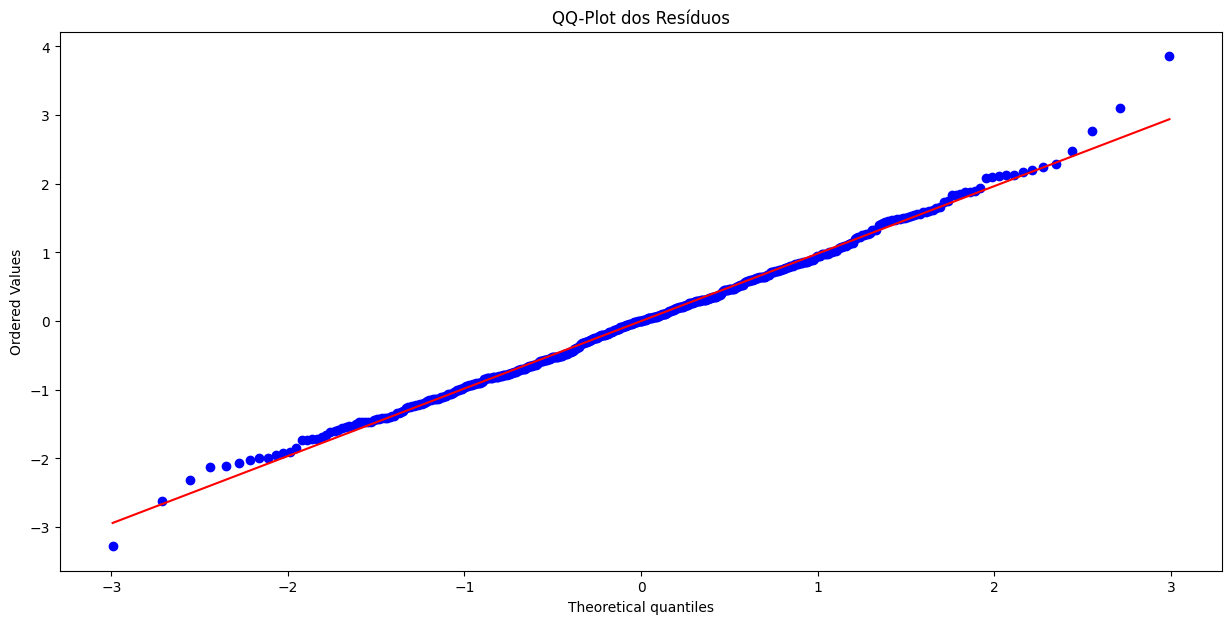

In [74]:
stats.probplot(residuos_modelo_arma, dist='norm', plot=plt)
plt.title('QQ-Plot dos Resíduos')
plt.show()

In [75]:
e,p_valor =stats.shapiro(residuos_modelo_arma,)
print('Estatistica de teste = %.3f, p-valor = %.3f' % (e,p_valor))

Estatistica de teste = 0.997, p-valor = 0.352


In [76]:
if p_valor >= 0.05:
  print('Não há evidências para rejeitar a hipótese nula. Os dados seguem uma distribuição normal.')
else:
  print('Rejeita-se a hipótese nula. Os dados não seguem uma distribuição normal.')

Não há evidências para rejeitar a hipótese nula. Os dados seguem uma distribuição normal.


### **Autocorrelação dos resíduos**

In [77]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# 'residuos' é a série temporal dos erros do modelo
resultado = acorr_ljungbox(residuos_modelo_arma, lags=[10], return_df=True)
print(resultado)


     lb_stat  lb_pvalue
10  7.385626   0.688607


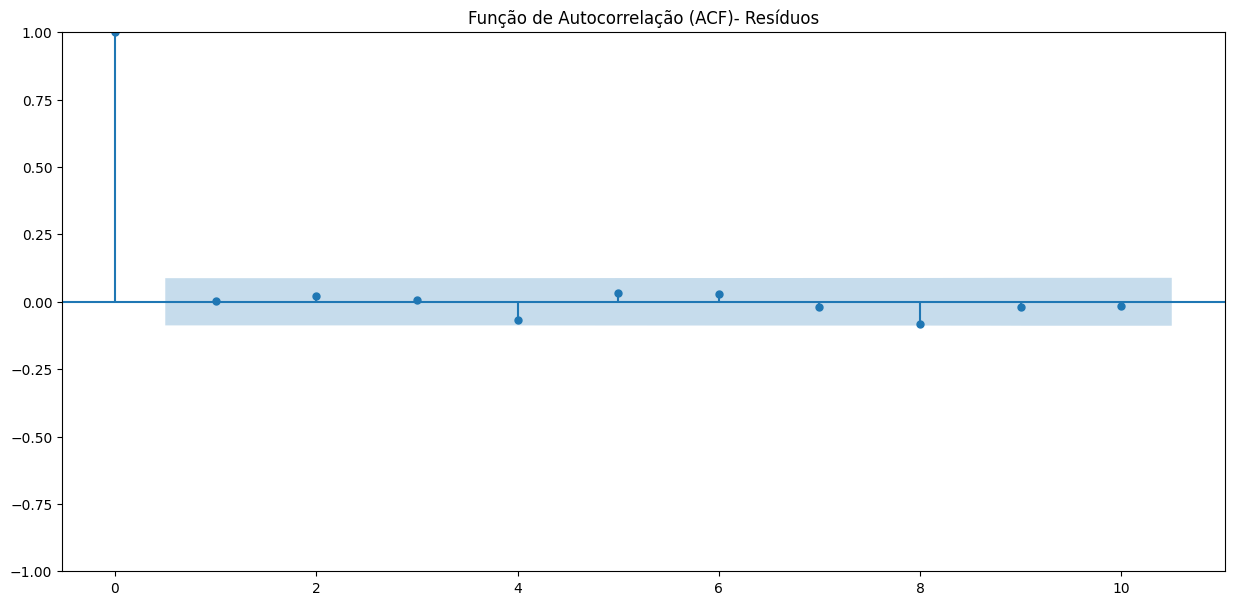

In [78]:
plot_acf(residuos_modelo_arma,lags=10, color='#1f77b4', title='Função de Autocorrelação (ACF)- Resíduos')
plt.show()

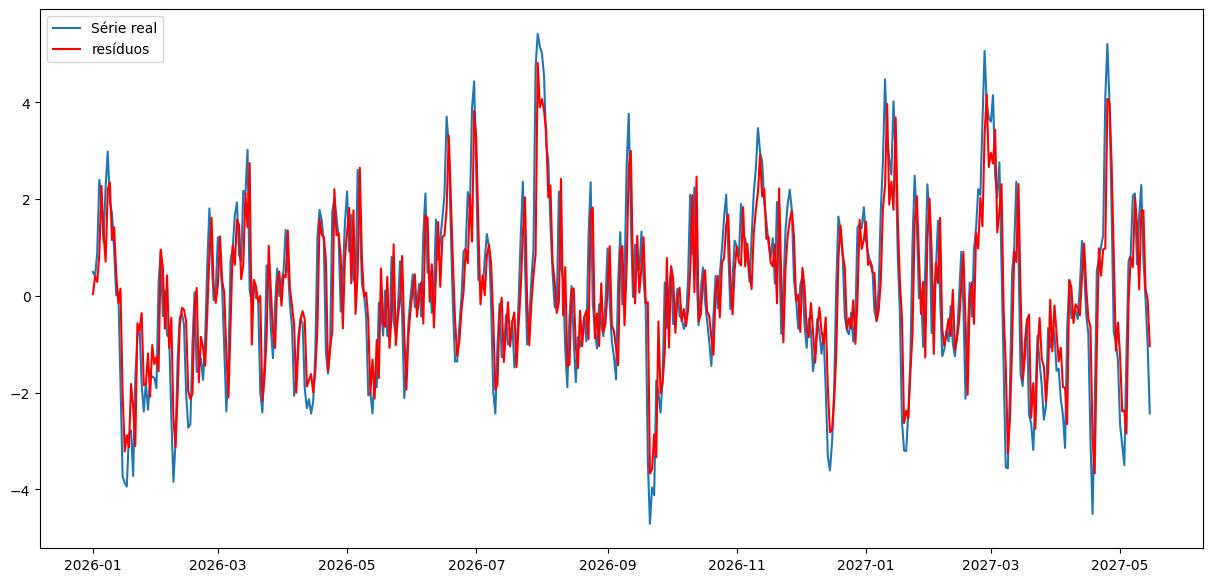

In [79]:
plt.plot(serie_modelo_arma, label  ="Série real")
plt.plot(serie_modelo_arma -residuos_modelo_arma, color ='red', label ="resíduos")
plt.legend(loc = 'best')
plt.show()

# **Aplicando o modelo ARMA**

In [80]:
modelo_arma_result.fittedvalues

,0
2026-01-01,0.034949
2026-01-02,0.407929
2026-01-03,0.289444
2026-01-04,0.848627
2026-01-05,2.272164
...,...
2027-05-11,1.767372
2027-05-12,1.767032
2027-05-13,0.145160
2027-05-14,-0.083665


In [81]:
previsao_modelo_arma = modelo_arma_result.forecast(10)

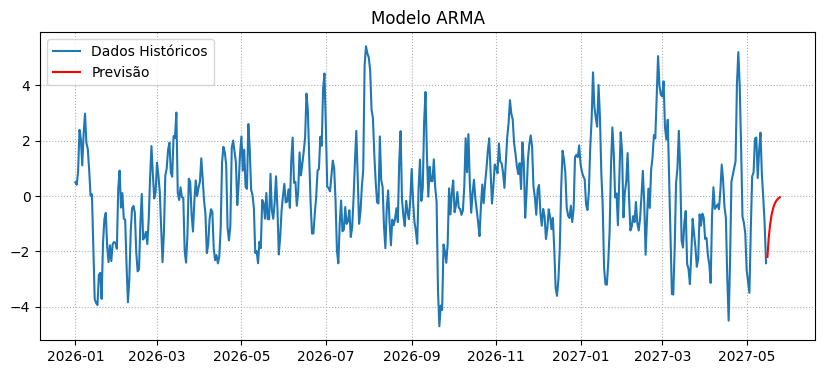

In [82]:
plt.figure(figsize=(10, 4))
plt.plot(serie_modelo_arma, label='Dados Históricos')
plt.plot(previsao_modelo_arma, color='red', label='Previsão')
plt.title('Modelo ARMA')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

## **Criando os intervalor de confiança para as previsões**

In [83]:
previsao_modelo_arma = modelo_arma_result.get_forecast(steps=7).summary_frame()

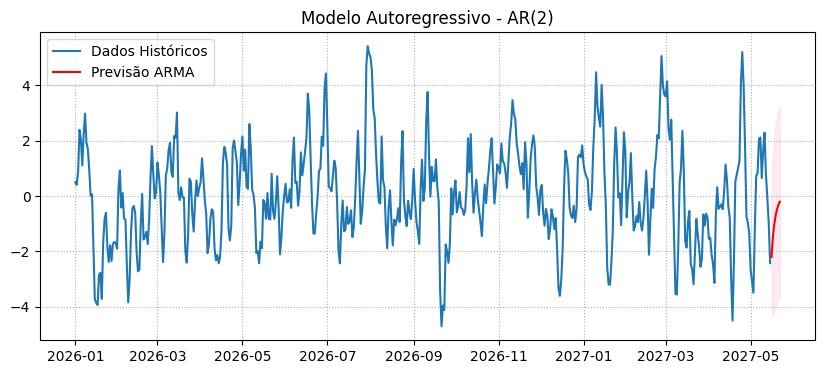

In [84]:
plt.figure(figsize=(10, 4))
plt.plot(serie_modelo_arma, label='Dados Históricos')
plt.plot(previsao_modelo_arma['mean'], color='red', label='Previsão ARMA')
plt.fill_between(previsao_modelo_arma.index, previsao_modelo_arma['mean_ci_lower'], previsao_modelo_arma['mean_ci_upper'], color='pink', alpha=0.3)
plt.title('Modelo Autoregressivo - AR(2)')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()